Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.90      0.95        10
           2       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



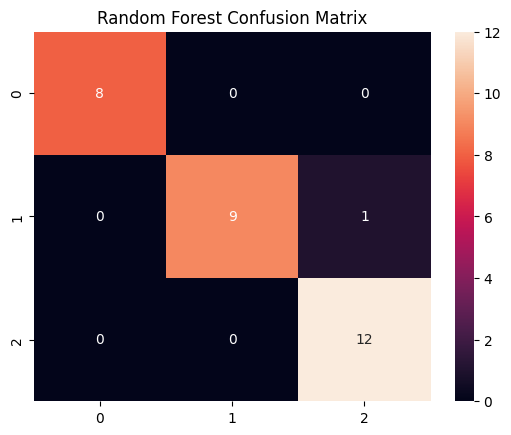

In [3]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2)

# Train model
rf = RandomForestClassifier(n_estimators=50, max_depth=3)
rf.fit(Xtr, ytr)

# Predict
yp = rf.predict(Xte)

# Accuracy + report
print("Accuracy:", accuracy_score(yte, yp))
print(classification_report(yte, yp))

# Confusion matrix (diagram)
sns.heatmap(confusion_matrix(yte, yp), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [4]:
# Import libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_recall_curve

# Train AdaBoost model
ada = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1
)

ada.fit(Xtr, ytr)

# Predict
yp2 = ada.predict(Xte)

# Accuracy + report
print("Accuracy:", accuracy_score(yte, yp2))
print(classification_report(yte, yp2))

# Confusion matrix
sns.heatmap(confusion_matrix(yte, yp2), annot=True, fmt='d')
plt.title("AdaBoost Confusion Matrix")
plt.show()

# Precision-Recall (for one class)
probs = ada.predict_proba(Xte)[:,1]
p, r, _ = precision_recall_curve(yte, probs, pos_label=1)
plt.plot(r, p)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Visualize one weak learner
plot_tree(ada.estimators_[0])
plt.title("Weak Learner Tree")
plt.show()

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'base_estimator'

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.90      0.95        10
           2       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



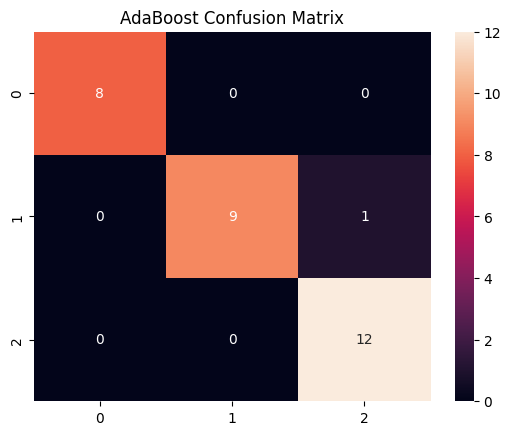

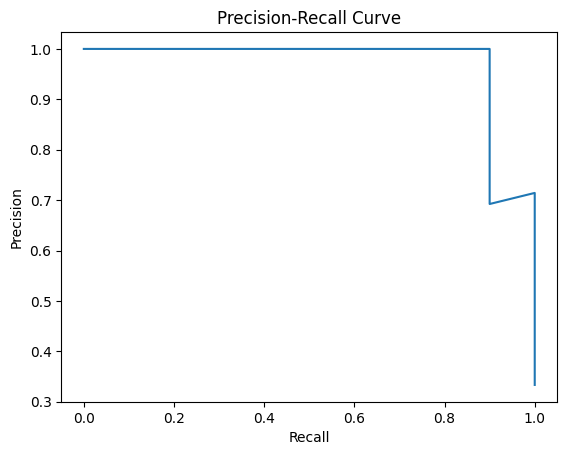

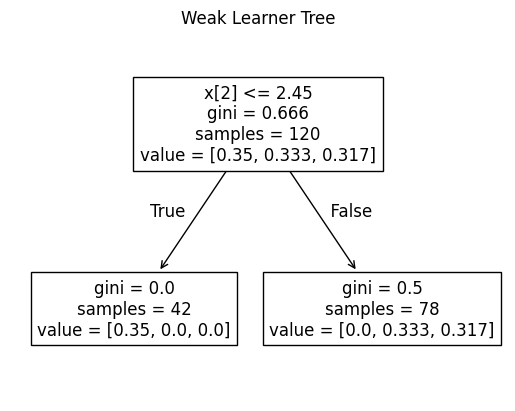

In [5]:
# Import libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_recall_curve

# Train AdaBoost model
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1
)

ada.fit(Xtr, ytr)

# Predict
yp2 = ada.predict(Xte)

# Accuracy + report
print("Accuracy:", accuracy_score(yte, yp2))
print(classification_report(yte, yp2))

# Confusion matrix
sns.heatmap(confusion_matrix(yte, yp2), annot=True, fmt='d')
plt.title("AdaBoost Confusion Matrix")
plt.show()

# Precision-Recall (for one class)
probs = ada.predict_proba(Xte)[:,1]
p, r, _ = precision_recall_curve(yte, probs, pos_label=1)
plt.plot(r, p)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Visualize one weak learner
plot_tree(ada.estimators_[0])
plt.title("Weak Learner Tree")
plt.show()